In [1]:
import os
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Rescaling # Changed 'rescaling' to 'Rescaling'

from google.colab import drive
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/CNN_project'
os.chdir(project_path)
# Create folder structure
os.makedirs(f'{project_path}/Jupyter_Notebooks', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn1', exist_ok=True)
os.makedirs(f'{project_path}/checkpoints/cnn2', exist_ok=True)
os.makedirs(f'{project_path}/models', exist_ok=True)
os.makedirs(f'{project_path}/metrics', exist_ok=True)

Mounted at /content/drive


In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
print(X_train.min(), X_train.max())

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
0 255


In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

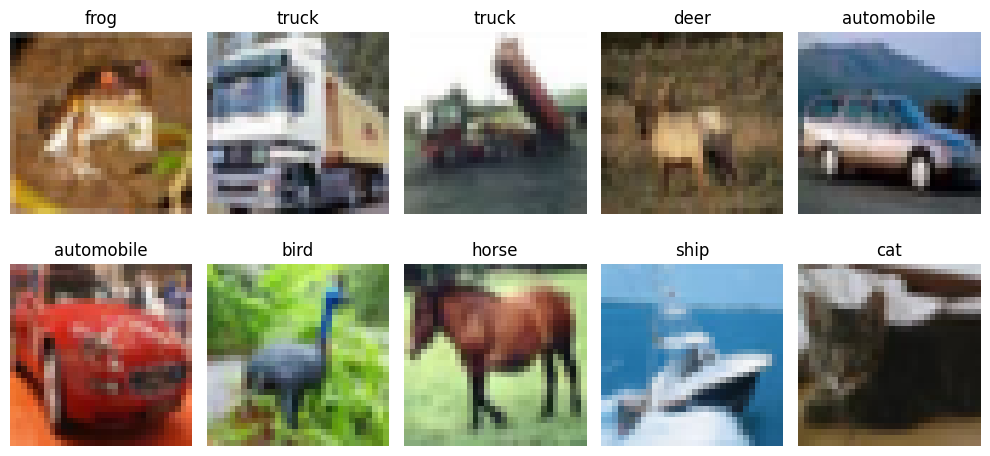

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

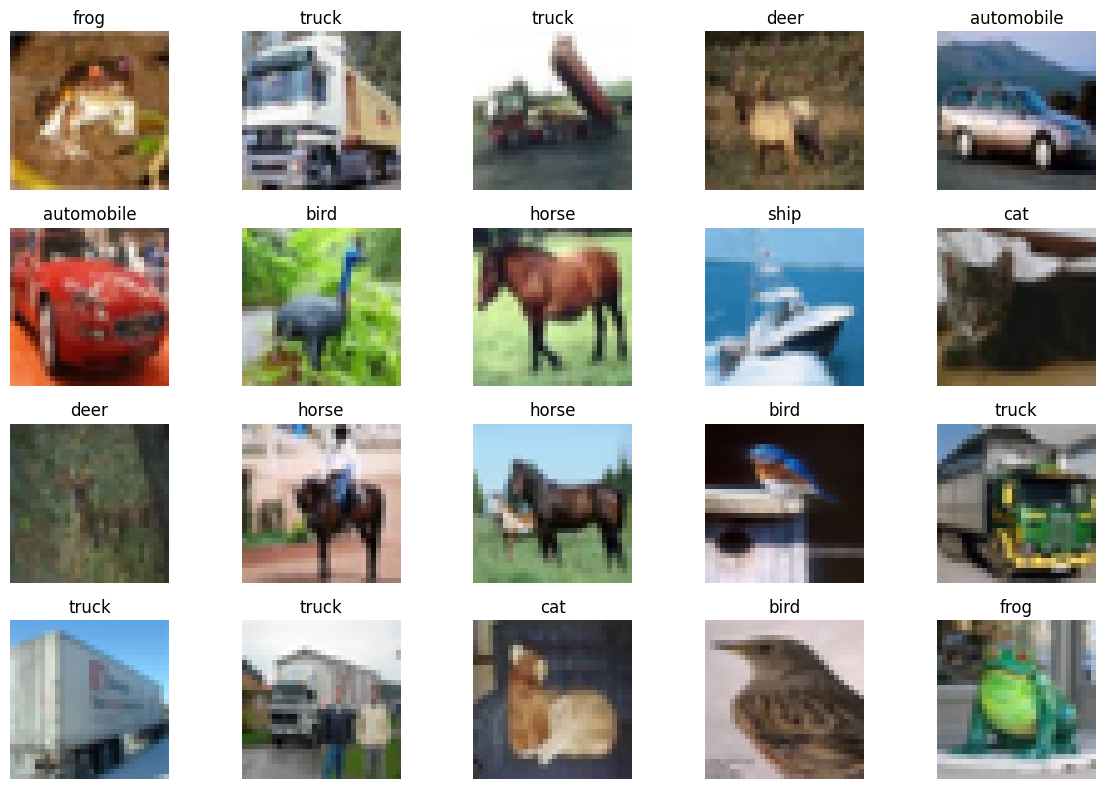

In [ ]:
plt.figure(figsize=(12, 8))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

labels = y_train.flatten()

class_counts = Counter(labels)

classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]

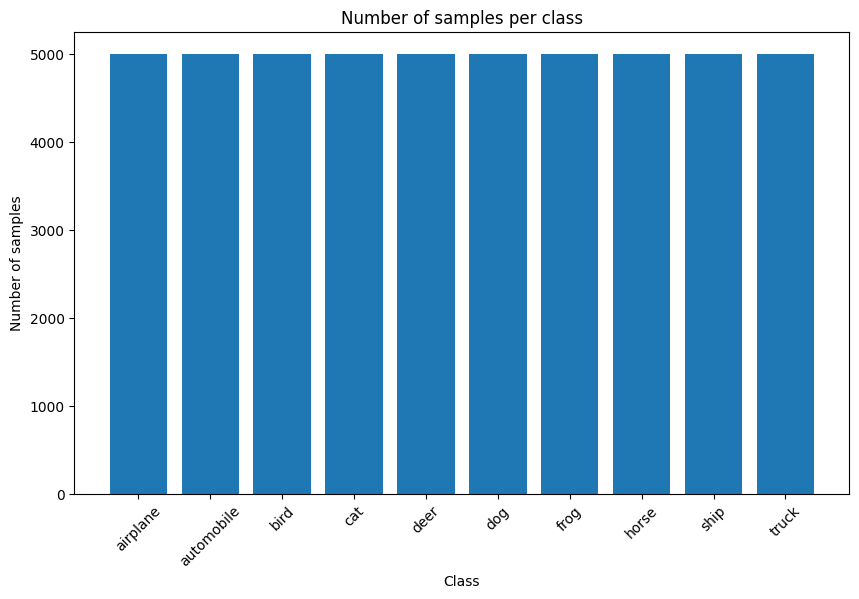

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(class_names, counts)
plt.xlabel('Class')
plt.ylabel('Number of samples')
plt.title('Number of samples per class')
plt.xticks(rotation=45)
plt.show()

for cls, count in zip(class_names, counts):
    print(f"{cls}: {count}")

## Data Processing

In [ ]:
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

In [ ]:
print(type(X_train[0]))
print(type(X_test[0]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
# We already have the correct shape, so we do not have to reshape

# Normalize
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Labels to one hot vectors
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [ ]:
print(type(X_train[0]))
print(type(X_test[0]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [ ]:
print(type(y_train_cat[0]))
print(type(y_test_cat[0]))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## Building CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
model = Sequential([
    # First convolutional layer with 32 filters, 3x3 kernel, ReLU activation
    # Input shape is 32x32 pixels, 3 color channels

    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),

    # Max pooling layer to reduce spatial dimensions by a factor of 2
    MaxPooling2D(2,2),

    # Second convolutional layer with 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3,3), activation='relu'),

    # Another max pooling layer to reduce size further
    MaxPooling2D(2,2),

    # Flatten the 2D feature maps into a 1D vector for dense layers
    Flatten(),

    # Fully connected (dense) layer with 64 neurons and ReLU activation
    #Learns intermediate features from the previous layers
    Dense(64, activation='relu'),

    # Output layer with 10 neurons (for 10 classes) and softmax activation
    #Produces the final probabilities for each class.
    Dense(10, activation='softmax') # why softmax, because we have 10 classes and not just biclass
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(
    X_train_norm,
    y_train_cat,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.4417 - loss: 1.5405 - val_accuracy: 0.5337 - val_loss: 1.3084
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5795 - loss: 1.1911 - val_accuracy: 0.6021 - val_loss: 1.1424
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6325 - loss: 1.0519 - val_accuracy: 0.6285 - val_loss: 1.0678
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6598 - loss: 0.9725 - val_accuracy: 0.6521 - val_loss: 1.0177
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6869 - loss: 0.9047 - val_accuracy: 0.6622 - val_loss: 0.9879
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7043 - loss: 0.8540 - val_accuracy: 0.6730 - val_loss: 0.9580
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7179 - loss: 0.8111 - val_accuracy: 0.6668 - val_loss: 0.9804
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7349 - loss: 0.7650 -

## Evaluation

In [ ]:
def acc_loss_viz(history):
  history_df = pd.DataFrame(history.history)

  acc = history_df['accuracy']
  val_acc = history_df['val_accuracy']
  loss = history_df['loss']
  val_loss = history_df['val_loss']

  max_val_acc = max(val_acc)
  epoch_max_acc = np.argmax(val_acc)

  min_val_loss = min(val_loss)
  epoch_min_loss = np.argmin(val_loss)


  plt.subplot(1, 2, 1)
  plt.plot(acc, label='Train')
  plt.plot(val_acc, label='Validation', color='orange')

  plt.axhline(y=max_val_acc, color='red', linestyle='--', alpha=0.5)
  plt.axvline(x=epoch_max_acc, color='green', linestyle=':', alpha=0.8)

  # Text labels
  plt.text(epoch_max_acc, max_val_acc, f' Acc: {max_val_acc:.4f}', color='red', fontweight='bold')
  plt.text(epoch_max_acc, plt.ylim()[0], f' Epoch: {epoch_max_acc}', color='green', fontweight='bold', ha='left', va='bottom')

  plt.title('Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(loc='lower right')
  plt.grid(True, alpha=0.3)


  # --- GRAPH 2: LOSS ---
  plt.subplot(1, 2, 2)
  plt.plot(loss, label='Train')
  plt.plot(val_loss, label='Validation', color='orange')

  plt.axhline(y=min_val_loss, color='blue', linestyle='--', alpha=0.5)
  plt.axvline(x=epoch_min_loss, color='green', linestyle=':', alpha=0.8)

  # Text labels
  plt.text(epoch_min_loss, min_val_loss, f' Loss: {min_val_loss:.4f}', color='blue', fontweight='bold')
  plt.text(epoch_min_loss, plt.ylim()[0], f' Epoch: {epoch_min_loss}', color='green', fontweight='bold', ha='left', va='bottom')

  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(loc='upper right')
  plt.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()


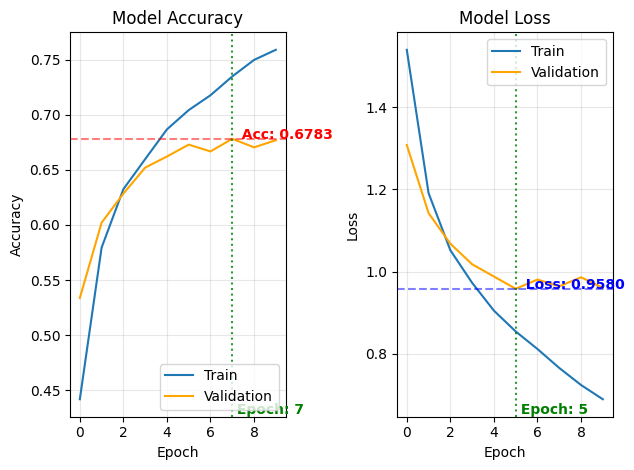

In [ ]:
acc_loss_viz(history)

from this graph we can see that the model is not generalizing, since the train accuracy keeps increasing but Validation loss stops improving and even goes up after epoch 5

## Accuracy, precision, recall

In [ ]:
def evaluate_model(model_name, model, X_test, y_test, X_train, y_train):
    score = model.evaluate(X_test, y_test, verbose=0)
    train_score = model.evaluate(X_train, y_train, verbose=0)
    return pd.DataFrame([{
        "Model": model_name,
        "Test Accuracy": score[1],
        "Test Loss": score[0],
        "Train Accuracy": train_score[1],
        "Train Loss": train_score[0]
    }])

In [ ]:
# Predict class probabilities
y_pred_probs = model.predict(X_test_norm)

# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)
y_true = y_test.ravel()  # original integer labels (ravel() Return a contiguous flattened array)

# Compute metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted')
rec = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")


new_row = evaluate_model(
    "Base_model",
    model,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

metrics_df = new_row
metrics_df

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.6735
Precision: 0.6844
Recall: 0.6735
F1 Score: 0.6769


,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843


## Confusion Matrix

In [ ]:
def confuse(y_true, y_pred, class_names=class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45)
    plt.title(title)
    plt.show()

    return cm

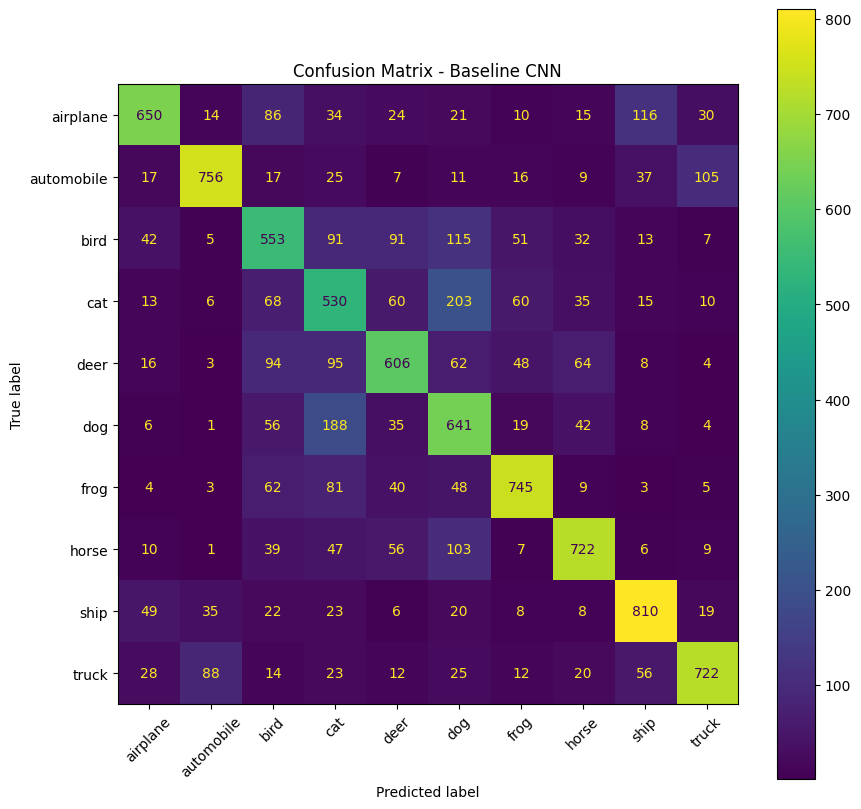

In [ ]:
cm_base = confuse(y_true, y_pred, title="Confusion Matrix - Baseline CNN")

In [ ]:
model.save(f'{project_path}/models/N_base_model.keras')

In [ ]:
model = load_model(f'{project_path}/models/N_base_model.keras')

## Test n°1: Early stop

In [ ]:
def build_cnn():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
model_name = "model_es"
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=f"{project_path}/models/N_{model_name}.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

In [ ]:
model_es = build_cnn()

history_es = model_es.fit(
    X_train_norm,
    y_train_cat,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4571 - loss: 1.5012 - val_accuracy: 0.5694 - val_loss: 1.2433
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5901 - loss: 1.1661 - val_accuracy: 0.5881 - val_loss: 1.1803
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6384 - loss: 1.0329 - val_accuracy: 0.6073 - val_loss: 1.1408
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6721 - loss: 0.9417 - val_accuracy: 0.6378 - val_loss: 1.0482
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7001 - loss: 0.8630 - val_accuracy: 0.6596 - val_loss: 0.9923
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7197 - loss: 0.8007 - val_accuracy: 0.6742 - val_loss: 0.9758
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7423 - loss: 0.7389 - val_accuracy: 0.6875 - val_loss: 0.9311
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7631 - loss: 0.6841 - 

In [ ]:
new_row = evaluate_model(
    "Early stopping",
    model_es,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174


## Test 2: Dropout
Dropout should reduce overfitting by making the model less dependent on specific neurons. I expect lower training accuracy, but potentially better test accuracy or test loss.

In [ ]:
model_dropout = Sequential([
  Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
  MaxPooling2D(2,2),
  Conv2D(64, (3,3), activation='relu'),
  MaxPooling2D(2,2),
  Flatten(),
  Dense(64, activation='relu'),
  Dropout(0.5),
  Dense(10, activation='softmax')
])

model_dropout.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dropout.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

In [ ]:
from functools import reduce
def create_callbacks(model_name, project_path, patience=5):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        filepath=f"{project_path}/models/N_{model_name}.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    )

    return [early_stop, checkpoint]

In [ ]:
callbacks = create_callbacks(model_name = "model_dropout", project_path = project_path, patience = 5)

In [ ]:
history_dropout = model_dropout.fit(
    X_train_norm,
    y_train_cat,
    epochs=30,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3347 - loss: 1.7954 - val_accuracy: 0.4778 - val_loss: 1.4699
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4517 - loss: 1.5005 - val_accuracy: 0.5413 - val_loss: 1.3057
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5010 - loss: 1.3800 - val_accuracy: 0.5773 - val_loss: 1.1917
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5366 - loss: 1.2960 - val_accuracy: 0.6079 - val_loss: 1.1108
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5594 - loss: 1.2296 - val_accuracy: 0.6238 - val_loss: 1.0786
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5795 - loss: 1.1784 - val_accuracy: 0.6375 - val_loss: 1.0337
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5964 - loss: 1.1367 - val_accuracy: 0.6327 - val_loss: 1.0303
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6085 - loss: 1.0972 - 

In [ ]:
new_row = evaluate_model(
    "+ Dropout",
    model_dropout,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801


In [ ]:
metrics_df.to_csv(f"{project_path}/metrics/N_metrics.csv", index=False)
metrics_df = pd.read_csv(f"{project_path}/metrics/N_metrics.csv")
metrics_df

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801


##Test 3: 3rd Conv Layer (128 kernels)
Convolutional layers specialize in extracting spatial and visual patterns from images. They preserve local structure and can learn increasingly complex features. Dense layers, instead, operate on flattened features and focus mainly on classification rather than visual feature extraction.

In [ ]:
model_3conv2D = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),

    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation = 'relu'),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.2),

    Dense(10, activation='softmax')
])

model_3conv2D.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,730 (495.04 KB)

 Trainable params: 126,730 (495.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.4014 - loss: 1.6273 - val_accuracy: 0.5325 - val_loss: 1.3261
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5509 - loss: 1.2582 - val_accuracy: 0.5916 - val_loss: 1.1487
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6111 - loss: 1.0999 - val_accuracy: 0.6206 - val_loss: 1.0617
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6550 - loss: 0.9884 - val_accuracy: 0.6773 - val_loss: 0.9440
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6834 - loss: 0.9096 - val_accuracy: 0.6765 - val_loss: 0.9362
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7042 - loss: 0.8447 - val_accuracy: 0.6972 - val_loss: 0.8799
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7236 - loss: 0.7919 - val_accuracy: 0.6826 - val_loss: 0.9430
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7406 - loss: 0.7408 - 

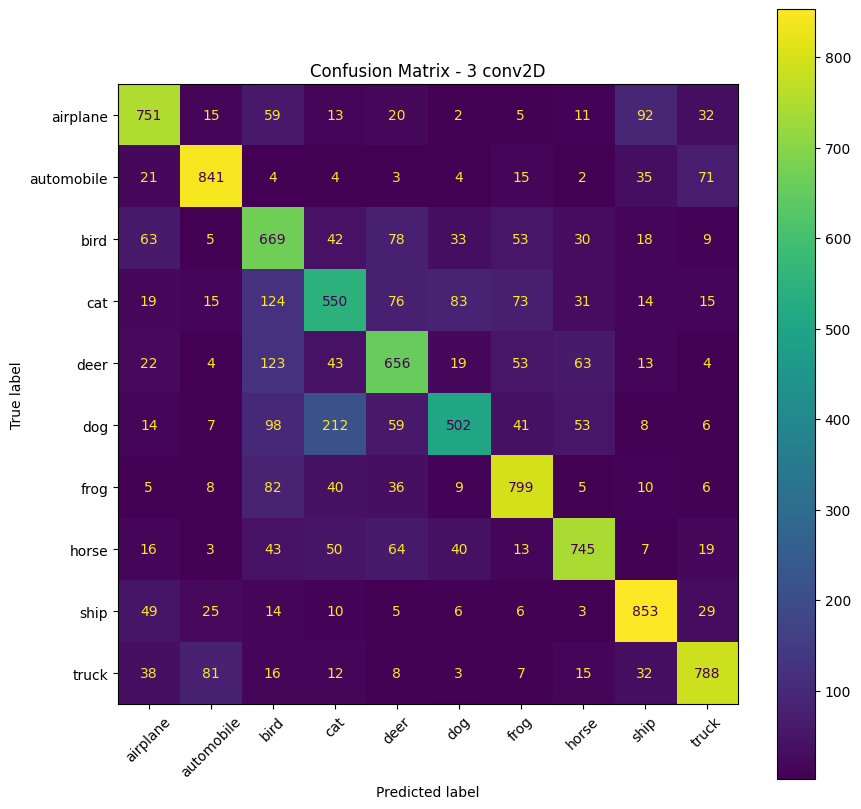

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801
3,3 conv2D,0.7002,0.895923,0.78644,0.623163
4,3 conv2D,0.7154,0.869863,0.80844,0.559011


In [ ]:
model_name = '3conv2D'
model_3conv2D.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

callbacks = create_callbacks(model_name = model_name,
                             project_path = project_path,
                             patience = 10)

history_3conv2D = model_3conv2D.fit(
    X_train_norm,
    y_train_cat,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks
)

new_row = evaluate_model(
    "3 conv2D",
    model_3conv2D,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

acc_loss_viz(history_3conv2D)

y_true = y_test.ravel()
# Predict class probabilities
y_pred_probs = model_3conv2D.predict(X_test_norm)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)

cm_3conv2D = confuse(y_true, y_pred, title="Confusion Matrix - 3 conv2D")

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df.to_csv(f"{project_path}/metrics/N_metrics.csv", index=False)
metrics_df

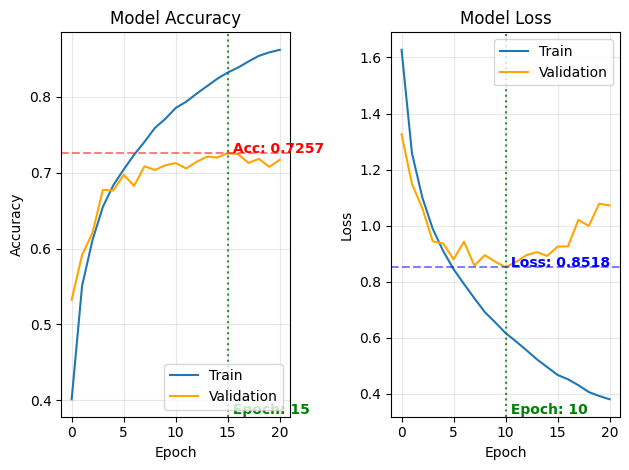

In [ ]:
acc_loss_viz(history_3conv2D)

##Test 4: Data augmentation
Data augmentation reduces overfitting because the model is exposed to varied versions of the same images during training. This makes it harder for the model to memorize exact pixel positions and forces it to learn more robust visual features, such as shapes, textures, and object parts.

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,730 (495.04 KB)

 Trainable params: 126,730 (495.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3665 - loss: 1.7258 - val_accuracy: 0.4876 - val_loss: 1.4536
Epoch 2/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4928 - loss: 1.4008 - val_accuracy: 0.5365 - val_loss: 1.2912
Epoch 3/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5444 - loss: 1.2745 - val_accuracy: 0.5885 - val_loss: 1.1639
Epoch 4/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5760 - loss: 1.1921 - val_accuracy: 0.5924 - val_loss: 1.1846
Epoch 5/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6007 - loss: 1.1306 - val_accuracy: 0.6391 - val_loss: 1.0312
Epoch 6/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6173 - loss: 1.0902 - val_accuracy: 0.6649 - val_loss: 0.9632
Epoch 7/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6295 - loss: 1.0493 - val_accuracy: 0.6801 - val_loss: 0.9172
Epoch 8/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6409 - loss: 1.0246 -

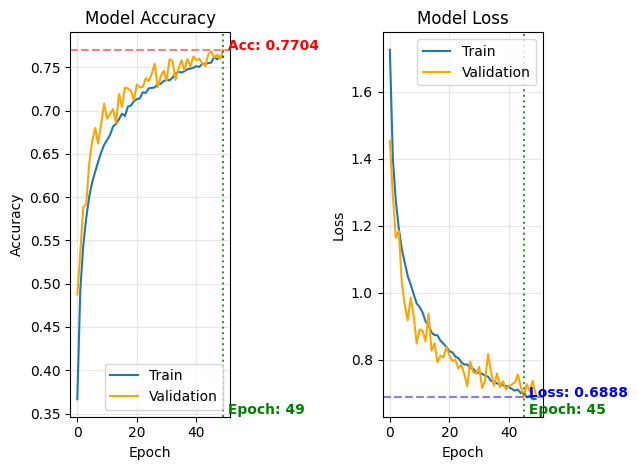

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


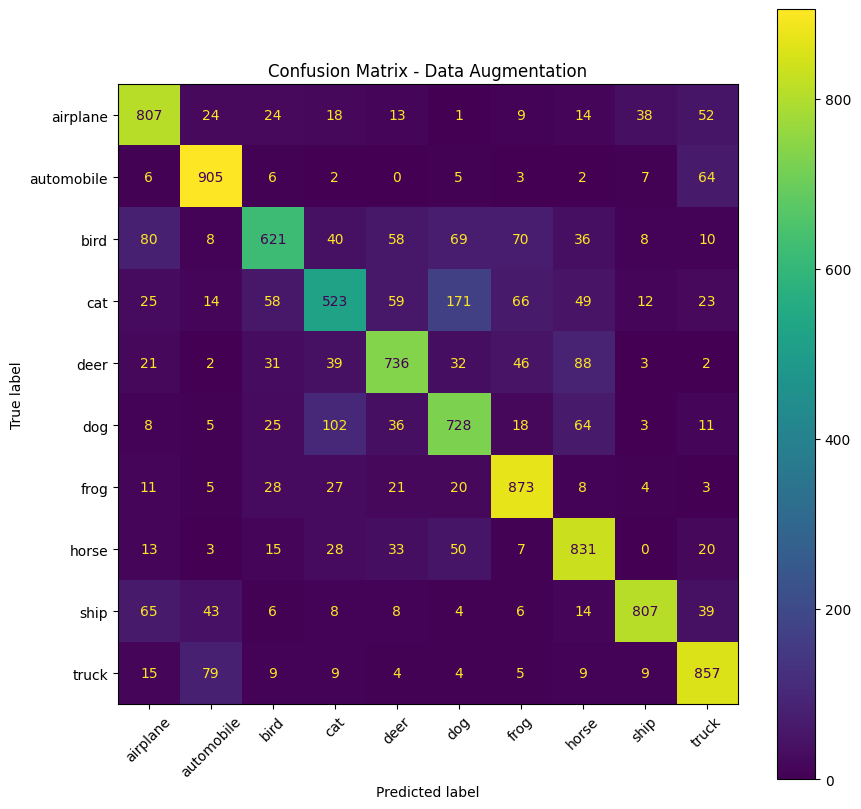

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801
3,3 conv2D,0.7154,0.869863,0.80844,0.559011
4,Dinamic Learning Rate,0.7601,0.705042,0.79616,0.582677
5,Dinamic Learning Rate,0.7720,0.680205,0.80940,0.543976
6,Dinamic Learning Rate,0.7547,0.722439,0.78466,0.607430
7,Dinamic Learning Rate,0.7611,0.697438,0.79008,0.599440
8,Dinamic Learning Rate,0.7677,0.698680,0.80092,0.567842
9,Data_augmentation,0.7688,0.693949,0.79908,0.579961


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1)
])

model_augmentation = Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model_augmentation.summary()


model_name = 'Data_augmentation'
model_augmentation.compile(
    optimizer= 'adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

callbacks = create_callbacks(model_name = model_name,
                             project_path = project_path,
                             patience = 10)

history_augmentation = model_augmentation.fit(
    X_train_norm,
    y_train_cat,
    epochs=50,
    validation_split=0.2,
    callbacks=callbacks
)

new_row = evaluate_model(
    model_name,
    model_augmentation,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

acc_loss_viz(history_augmentation)

y_true = y_test.ravel()
# Predict class probabilities
y_pred_probs = model_augmentation.predict(X_test_norm)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)

cm_augmentation = confuse(y_true, y_pred, title="Confusion Matrix - Data Augmentation")

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df.to_csv(f"{project_path}/metrics/N_metrics.csv", index=False)
metrics_df



##Test 5: Dynamic Learning Rate

In [ ]:
def create_callbacks(model_name, project_path, min_lr, patience, patience_lr, factor):
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        filepath=f"{project_path}/models/N_{model_name}.keras",
        monitor="val_loss",
        save_best_only=True,
        mode="min"
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=factor,
        patience=patience_lr,
        min_lr= min_lr,
        verbose = 1
    )

    return [early_stop, checkpoint, reduce_lr]




Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,730 (495.04 KB)

 Trainable params: 126,730 (495.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3497 - loss: 1.7508 - val_accuracy: 0.4513 - val_loss: 1.5050 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.4684 - loss: 1.4602 - val_accuracy: 0.5523 - val_loss: 1.2473 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5189 - loss: 1.3383 - val_accuracy: 0.5762 - val_loss: 1.2016 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5521 - loss: 1.2517 - val_accuracy: 0.5908 - val_loss: 1.1460 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5787 - loss: 1.1928 - val_accuracy: 0.6289 - val_loss: 1.0407 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.5982 - loss: 1.1408 - val_accuracy: 0.6465 - val_loss: 1.0111 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.

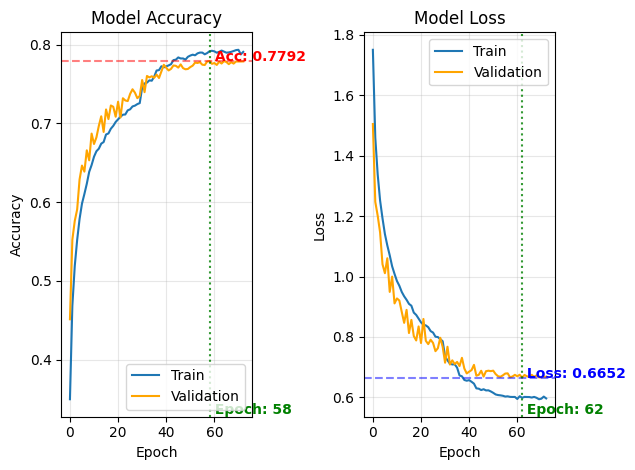

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


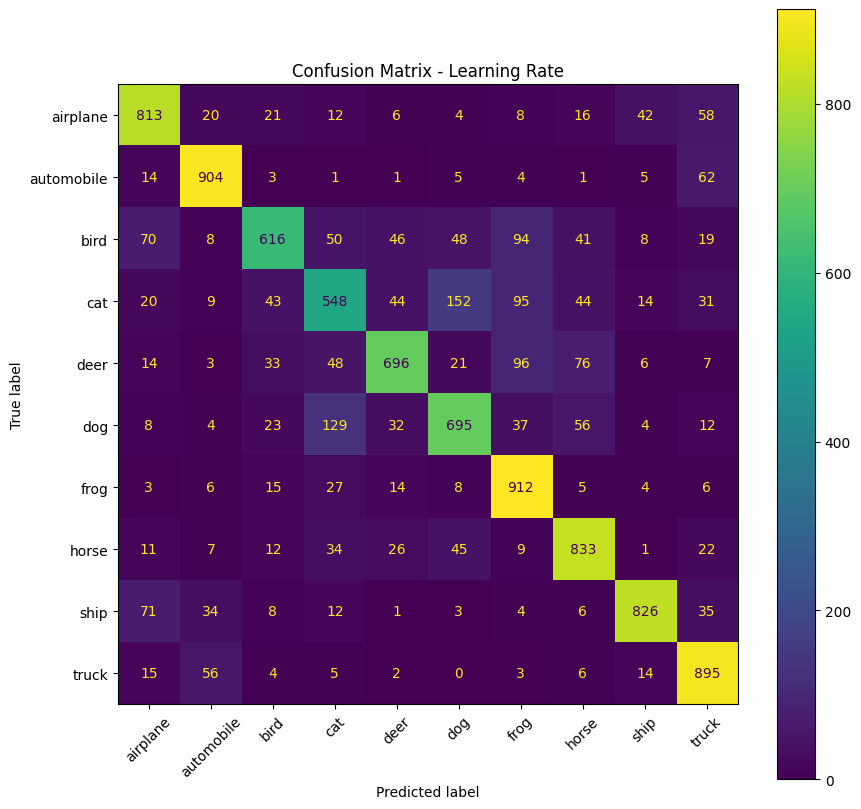

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801
3,3 conv2D,0.7154,0.869863,0.80844,0.559011
4,Dinamic Learning Rate,0.7601,0.705042,0.79616,0.582677
5,Dinamic Learning Rate,0.7720,0.680205,0.80940,0.543976
6,Dinamic Learning Rate,0.7547,0.722439,0.78466,0.607430
7,Dinamic Learning Rate,0.7611,0.697438,0.79008,0.599440
8,Dinamic Learning Rate,0.7677,0.698680,0.80092,0.567842
9,Data_augmentation,0.7688,0.693949,0.79908,0.579961


In [ ]:
model_lr = Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model_lr.summary()

min_lr = 1e-5
patience = 10
patience_lr = 3
factor = 0.5

model_name = f'LR (lr:{min_lr}-p:{patience_lr}-f:{factor})'
model_lr.compile(
    optimizer= 'adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

callbacks = create_callbacks(model_name,
                             project_path,
                             min_lr,
                             patience,
                             patience_lr,
                             factor)


history_lr = model_lr.fit(
    X_train_norm,
    y_train_cat,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks
)

new_row = evaluate_model(
    model_name,
    model_lr,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

acc_loss_viz(history_lr)

y_true = y_test.ravel()
# Predict class probabilities
y_pred_probs = model_lr.predict(X_test_norm)
# Convert probabilities to class predictions
y_pred = y_pred_probs.argmax(axis=1)

cm_lr = confuse(y_true, y_pred, title="Confusion Matrix - Learning Rate")

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df.to_csv(f"{project_path}/metrics/N_metrics.csv", index=False)
metrics_df

The confusion matrix shows that the main errors remain concentrated among visually similar animal classes, especially cat and dog. Adding a fourth convolutional layer did not substantially reduce these confusions, suggesting that the model’s limitation is not only depth but also the low image resolution and the difficulty of extracting fine-grained features from CIFAR-10 images.

##Test 6: 4th Convolutional layer (256 kernels)

In [ ]:
model_4conv = Sequential([
    layers.Input(shape=(32, 32, 3)),
    data_augmentation,
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation = 'relu'),
    MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation = 'relu', padding='same'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model_4conv.summary()

min_lr = 1e-5
patience = 10
patience_lr = 3
factor = 0.5

model_name = f'4conv (lr:{min_lr}-p:{patience_lr}-f:{factor})'
model_4conv.compile(
    optimizer= 'adam',
    loss="categorical_crossentropy",
    metrics=["accuracy"]
    )

callbacks = create_callbacks(model_name,
                             project_path,
                             min_lr,
                             patience,
                             patience_lr,
                             factor)



Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_17 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 2, 2, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,514 (1.55 MB)

 Trainable params: 405,514 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.3535 - loss: 1.7372 - val_accuracy: 0.4875 - val_loss: 1.4233 - learning_rate: 0.0010
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5033 - loss: 1.3818 - val_accuracy: 0.5377 - val_loss: 1.3323 - learning_rate: 0.0010
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5568 - loss: 1.2539 - val_accuracy: 0.6134 - val_loss: 1.1043 - learning_rate: 0.0010
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5834 - loss: 1.1749 - val_accuracy: 0.6296 - val_loss: 1.0569 - learning_rate: 0.0010
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6149 - loss: 1.0913 - val_accuracy: 0.6353 - val_loss: 1.0304 - learning_rate: 0.0010
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6378 - loss: 1.0436 - val_accuracy: 0.6623 - val_loss: 0.9778 - learning_rate: 0.0010
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.

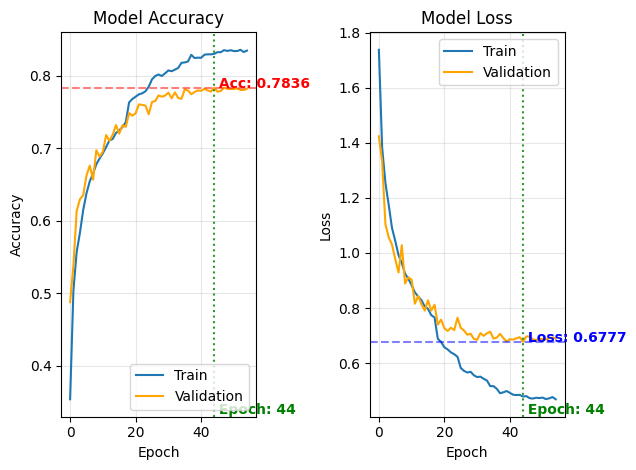

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


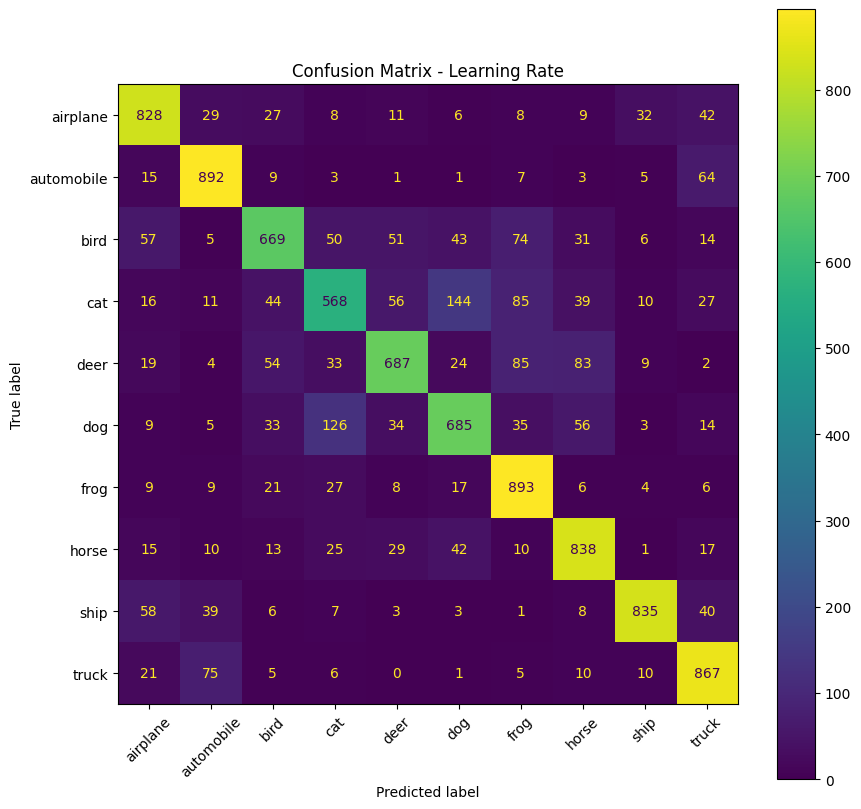

,Model,Test Accuracy,Test Loss,Train Accuracy,Train Loss
0,Base_model,0.6735,0.984074,0.76674,0.686843
1,Early stopping,0.6866,0.937950,0.76964,0.682174
2,+ Dropout,0.6875,0.912646,0.77728,0.658801
3,3 conv2D,0.7154,0.869863,0.80844,0.559011
4,Dinamic Learning Rate,0.7601,0.705042,0.79616,0.582677
5,Dinamic Learning Rate,0.7720,0.680205,0.80940,0.543976
6,Dinamic Learning Rate,0.7547,0.722439,0.78466,0.607430
7,Dinamic Learning Rate,0.7611,0.697438,0.79008,0.599440
8,Dinamic Learning Rate,0.7677,0.698680,0.80092,0.567842
9,Data_augmentation,0.7688,0.693949,0.79908,0.579961


In [ ]:
history_4conv = model_4conv.fit(
    X_train_norm,
    y_train_cat,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks
)

new_row = evaluate_model(
    model_name,
    model_4conv,
    X_test_norm,
    y_test_cat,
    X_train_norm,
    y_train_cat
)

acc_loss_viz(history_4conv)

y_true = y_test.ravel()

y_pred_probs = model_4conv.predict(X_test_norm)

y_pred = y_pred_probs.argmax(axis=1)

cm_4conv = confuse(y_true, y_pred, title="Confusion Matrix - Learning Rate")

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)
metrics_df.to_csv(f"{project_path}/metrics/N_metrics.csv", index=False)
metrics_df

Adding a fourth convolutional layer slightly improved test accuracy but increased test loss and widened the train-test gap. This suggests that the additional capacity helped the model fit the training data better, but did not clearly improve generalization. Therefore, the 3-convolutional-block model with data augmentation and dynamic learning rate remains the more balanced custom CNN.

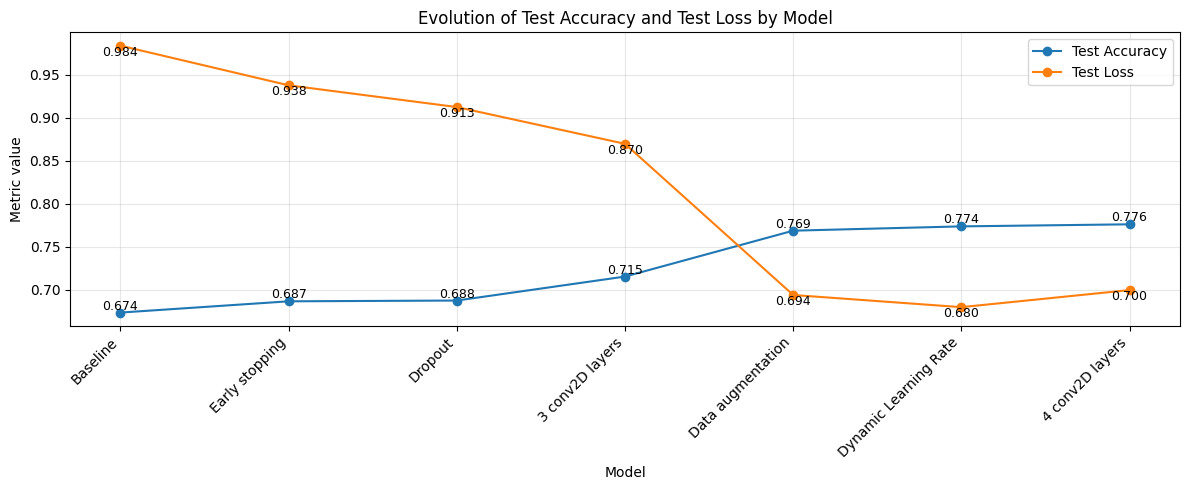

In [5]:
# Load data
df = pd.read_csv(f"{project_path}/metrics/N_metrics.csv")

# Optional: clean column names
df.columns = df.columns.str.strip()

# Create x positions
x = range(len(df))

plt.figure(figsize=(12, 5))

# Test Accuracy
plt.plot(x, df["Test Accuracy"], marker="o", label="Test Accuracy")

# Test Loss
plt.plot(x, df["Test Loss"], marker="o", label="Test Loss")

# Use model names as labels on x-axis
plt.xticks(x, df["Model"], rotation=45, ha="right")

# Add value labels to each point
for i, row in df.iterrows():
    plt.text(i, row["Test Accuracy"], f'{row["Test Accuracy"]:.3f}',
             ha="center", va="bottom", fontsize=9)

    plt.text(i, row["Test Loss"], f'{row["Test Loss"]:.3f}',
             ha="center", va="top", fontsize=9)

plt.title("Evolution of Test Accuracy and Test Loss by Model")
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()